# ResNet-Classification-CIFAR10

## 准备工作

### 1.准备必要的库

In [1]:
#导入必要的库
import os
import time
import random
import copy
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
import torch.nn as nn
from torch.nn import functional as F
from torch.autograd import Variable

import torchvision
import torchvision.datasets as datasets
from torchvision import transforms as T
from torchvision import models as m

from torchinfo import summary

In [2]:
#设置中文字体，避免出现乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

###  2.设置随机种子

In [3]:
#随机种子：0
seed=0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### 3.准备数据集

In [4]:
#数据预处理

#针对训练集
transformTr=T.Compose([T.RandomCrop(32,padding=4)#扩充到40再随机裁剪为32，训练平移不变性
                       ,T.RandomRotation(degrees=[-5,5])#-5°到5°之间随机旋转，训练旋转不变性
                       ,T.RandomHorizontalFlip()#随机水平翻转，增加泛化能力
                       ,T.ToTensor()
                       ,T.Normalize(mean=[0.4915,0.4823,0.4468]
                                   ,std=[0.2470,0.2435,0.2616])#数据归一化(针对本数据集)
                       ,T.RandomErasing(p=0.5#对训练集数据进行随机擦除，增强泛化能力
                                        ,scale=(0.02, 0.33)
                                        ,ratio=(0.3, 3.3)
                                        ,value=0
                                        ,inplace=False)
                      ])
#针对训练集
transformTe=T.Compose([T.CenterCrop(32)#几乎不进行任何操作，仅为美观
                       ,T.ToTensor()
                       ,T.Normalize(mean=[0.4915,0.4823,0.4468]
                                    ,std=[0.2470,0.2435,0.2616])
                       ])


### 4.数据集下载

In [5]:
#训练集下载
trainset=datasets.CIFAR10(root='./cifar10'
                          ,train=True
                          ,download=True
                          ,transform=transformTr
                         )
#测试集下载
testset=datasets.CIFAR10(root='./cifar10'
                         ,train=False
                         ,download=True
                         ,transform=transformTe
                        )

In [6]:
#检查
print("train:",len(trainset),"test:",len(testset))

train: 50000 test: 10000


### 5.划分训练集、测试集与验证集

In [7]:
#从测试集内划分出验证集
testset,valset=torch.utils.data.random_split(testset,[5000,5000])
print("test:",len(testset),"val:",len(valset))

test: 5000 val: 5000


### 6.分割小批量

In [8]:
#尽可能使数据集能被BatchSize整除，将Batch_Size设置为250
Batch_Size=250
trainloader=torch.utils.data.DataLoader(trainset
                                        ,batch_size=Batch_Size
                                        ,shuffle=True
                                        ,num_workers=2
                                        ,drop_last=True
                                        ,pin_memory=True#加速cpu->gpu传输
                                        ,prefetch_factor=8#增加预取缓冲
                                        ,persistent_workers=True#消除Epoch间进程重启
                                       )
valloader=torch.utils.data.DataLoader(valset
                                        ,batch_size=Batch_Size
                                        ,shuffle=False
                                        ,num_workers=2
                                        ,drop_last=False
                                       ,pin_memory=True#加速cpu->gpu传输
                                        ,prefetch_factor=8#增加预取缓冲
                                        ,persistent_workers=True#消除Epoch间进程重启
                                       )
testloader=torch.utils.data.DataLoader(testset
                                        ,batch_size=Batch_Size
                                        ,shuffle=False
                                        ,num_workers=2
                                        ,drop_last=False
                                        ,pin_memory=True#加速cpu->gpu传输
                                        ,prefetch_factor=8#增加预取缓冲
                                        ,persistent_workers=True#消除Epoch间进程重启
                                       )


### 7.查看数据集

In [9]:
#数据集
print(f'种类:{trainset.classes}\n')
print(f'训练集形状:{trainset.data.shape}\n')
print(f'种类对应编号:{trainset.class_to_idx}\n')
print(f'训练集Batch数:{len(trainloader)}')

种类:['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

训练集形状:(50000, 32, 32, 3)

种类对应编号:{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}

训练集Batch数:200


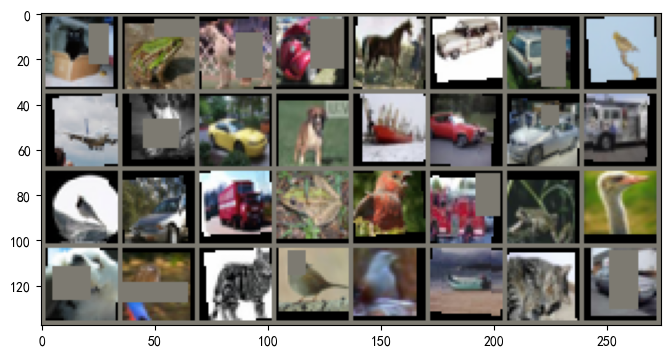

In [10]:
#原始图像
def imshow(img):
    #反标准化
    mean=np.array([0.4915, 0.4823, 0.4468])
    std=np.array([0.2470, 0.2435, 0.2616])
    img=img.numpy()
    img=img*std[:,None, None]+mean[:,None,None]
    img=np.transpose(img,(1,2,0))
    img=np.clip(img,0,1)
    plt.imshow(img)
    plt.show()
    
images,labels=next(iter(trainloader))
plt.figure(figsize=(8,12))
imshow(torchvision.utils.make_grid(images[:32]))

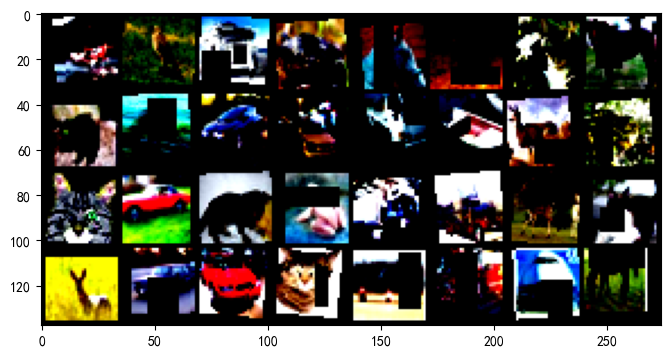

In [11]:
#准化后的图像
def imshow(img):
    #反标准化
    img=img.numpy()
    img=np.transpose(img,(1,2,0))
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.show()

images,labels=next(iter(trainloader))
plt.figure(figsize=(8,12))
imshow(torchvision.utils.make_grid(images[:32]))

## 进行实验

### 1.搭建网络

In [12]:
#构建残差块
class BasicBlock(nn.Module):
    expansion=1
    
    def __init__(self,in_channels,out_channels,stride=1,downsample=None):
        super(BasicBlock,self).__init__()
        
        self.conv1=nn.Conv2d(in_channels,out_channels,kernel_size=3,stride=stride,padding=1,bias=False)
        self.bn1=nn.BatchNorm2d(out_channels)
        
        self.conv2=nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1,bias=False)
        self.bn2=nn.BatchNorm2d(out_channels)
        
        self.downsample=downsample
        self.prelu=nn.PReLU()
        
    def forward(self,x):
        identity=x
        
        out=self.conv1(x)
        out=self.bn1(out)
        out=self.prelu(out)
        
        out=self.conv2(out)
        out=self.bn2(out)
        
        if self.downsample!=None:
            identity=self.downsample(x)
        
        out+=identity
        out=self.prelu(out)
        
        return out

In [13]:
#搭建网络
class ResNet(nn.Module):
    def __init__(self,n,num_classes=10):
        super().__init__()
        self.in_channels=16
        
        self.conv1=nn.Conv2d(3,16,kernel_size=3,padding=1,bias=False)
        self.bn1=nn.BatchNorm2d(16)
        self.prelu=nn.PReLU()
        
        self.layer1=self.make_layer(16,n,stride=1)
        self.layer2=self.make_layer(32,n,stride=2)
        self.layer3=self.make_layer(64,n,stride=2)
        
        self.avgpool=nn.AdaptiveAvgPool2d((1,1))
        self.fc=nn.Linear(64,num_classes)
        
    def make_layer(self,out_channels,num_blocks,stride):
        downsample=None
        
        if stride!=1 or self.in_channels!=out_channels:
            downsample=nn.Sequential(nn.Conv2d(self.in_channels,out_channels,kernel_size=1,stride=stride,bias=False)
                                   ,nn.BatchNorm2d(out_channels))
        
        layers=[]
        layers.append(BasicBlock(in_channels=self.in_channels
                               ,out_channels=out_channels
                               ,stride=stride
                               ,downsample=downsample))
        
        self.in_channels=out_channels
        
        for i in range(1,num_blocks):
            layers.append(BasicBlock(in_channels=self.in_channels
                                    ,out_channels=out_channels
                                    ,stride=1
                                    ,downsample=None))
        
        return nn.Sequential(*layers)
    
    def forward(self,x):
        x=self.conv1(x)
        x=self.bn1(x)
        x=self.prelu(x)
        
        x=self.layer1(x)
        x=self.layer2(x)
        x=self.layer3(x)
        
        x=self.avgpool(x)
        x=torch.flatten(x,1)
        x=self.fc(x)
        
        return x

In [14]:
#选择训练设备与简要测试
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
net=ResNet(1)
summary(net)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            432
├─BatchNorm2d: 1-2                       32
├─PReLU: 1-3                             1
├─Sequential: 1-4                        --
│    └─BasicBlock: 2-1                   --
│    │    └─Conv2d: 3-1                  2,304
│    │    └─BatchNorm2d: 3-2             32
│    │    └─Conv2d: 3-3                  2,304
│    │    └─BatchNorm2d: 3-4             32
│    │    └─PReLU: 3-5                   1
├─Sequential: 1-5                        --
│    └─BasicBlock: 2-2                   --
│    │    └─Conv2d: 3-6                  4,608
│    │    └─BatchNorm2d: 3-7             64
│    │    └─Conv2d: 3-8                  9,216
│    │    └─BatchNorm2d: 3-9             64
│    │    └─Sequential: 3-10             576
│    │    └─PReLU: 3-11                  1
├─Sequential: 1-6                        --
│    └─BasicBlock: 2-3                   --
│    │    └─Conv

### 2.训练网络

In [15]:
#保存函数
def SaveNet(best,n):
    if not os.path.exists('./savenet'):
        os.makedirs('./savenet')
    save_path=f'./savenet/ResNet_{6*n+2}.pth'
    torch.save(best.state_dict(),save_path)

In [16]:
#训练函数
def TrainFunction(net, config, trainloader, valloader):
    net = net.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)#增强泛化能力

    prelu_params = []
    other_params = []
    for name, param in net.named_parameters():
        if 'prelu' in name:  # 检查参数名是否包含 prelu
            prelu_params.append(param)
        else:
            other_params.append(param)
    
    optimizer = optim.SGD([{'params': other_params, 'weight_decay': config['weight_decay']}
                           ,{'params': prelu_params, 'weight_decay': 0.0}]
                           ,lr=config['lr'], momentum=config['momentum'])

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config['milestones'],
        gamma=config['gamma']
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_acc = 0
    best_state_dict=None

    for epoch in range(config['epochs']):

        start_time = time.time()

        net.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in trainloader:

            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        scheduler.step()
        train_loss /= len(trainloader)
        train_acc = train_correct / train_total
        net.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in valloader:
                images, labels = images.to(device), labels.to(device)
                outputs = net(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(valloader)
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state_dict=copy.deepcopy(net.state_dict())

        print(
            f'Epoch [{epoch+1}/{config["epochs"]}]  '
            f'Train Loss:{train_loss:.4f}  '
            f'Train Acc:{train_acc:.4f}  '
            f'Val Loss:{val_loss:.4f}  '
            f'Val Acc:{val_acc:.4f}  '
            f'用时:{time.time()-start_time:.1f}s'
        )

    best_model=copy.deepcopy(net)
    best_model.load_state_dict(best_state_dict)
    
    return history, best_model

In [17]:
#设置超参数
config = {
    'lr': 0.1,
    'momentum': 0.9,
    'weight_decay': 0.001,
    'milestones': [64,96],
    'gamma': 0.1,
    'epochs': 128
}

In [18]:
#训练
n_list=[1,2,3,4,5,6,7,8,9]
history_list=[]
best_list=[]

for n in n_list:
    net=ResNet(n)
    print(f"训练网络 ResNet{6*n+2}")
    history, best=TrainFunction(net,config,trainloader,valloader)
    history_list.append(history)
    best_list.append(best)
    SaveNet(best,n)

训练网络 ResNet8
Epoch [1/128]  Train Loss:1.8256  Train Acc:0.3704  Val Loss:1.8050  Val Acc:0.4304  用时:25.4s
Epoch [2/128]  Train Loss:1.5712  Train Acc:0.5095  Val Loss:1.6693  Val Acc:0.4934  用时:17.5s
Epoch [3/128]  Train Loss:1.4531  Train Acc:0.5747  Val Loss:2.1671  Val Acc:0.4148  用时:17.2s
Epoch [4/128]  Train Loss:1.3847  Train Acc:0.6052  Val Loss:2.0435  Val Acc:0.4590  用时:17.5s
Epoch [5/128]  Train Loss:1.3434  Train Acc:0.6286  Val Loss:1.5081  Val Acc:0.5744  用时:17.4s
Epoch [6/128]  Train Loss:1.3051  Train Acc:0.6455  Val Loss:1.6140  Val Acc:0.5792  用时:17.5s
Epoch [7/128]  Train Loss:1.2904  Train Acc:0.6540  Val Loss:1.6443  Val Acc:0.5228  用时:17.8s
Epoch [8/128]  Train Loss:1.2819  Train Acc:0.6571  Val Loss:2.0852  Val Acc:0.4520  用时:17.4s
Epoch [9/128]  Train Loss:1.2620  Train Acc:0.6674  Val Loss:2.0293  Val Acc:0.4548  用时:17.5s
Epoch [10/128]  Train Loss:1.2504  Train Acc:0.6737  Val Loss:1.5487  Val Acc:0.5614  用时:17.3s
Epoch [11/128]  Train Loss:1.2329  Train Acc:0

*用epoch=2进行调试*

#### (1).使用的num_workers过低导致GPU无法满负荷运行，Batch_Size过小无法有效利用显存

更改num_workers=8,Batch_Size=250

#### (2).num_workers过高导致GPU无法获得一个单独的进程用于控制，GPU反而长期0占用

更改num_workers=4

更改num_workers=2

#### (3).为更好的利用显存，再次扩大Batch_Size

Batch_Size=500

Batch_Size=500,lr=0.2,num_workers=4

num_workers=2

#### (4).对应我们使用的prelu，我们要对参数进行调整

#### (5).将最优模型参数的传递改为先保存最后一次性传递

#### (6).降低GPU闲置时间

    pin_memory=True,          # 加速CPU->GPU传输
    prefetch_factor=8,        # 增加预取缓冲
    persistent_workers=True   # 消除Epoch间进程重启

*用epoch=16进行测试*

测试出相当好的结果，进行256此训练

#### (7).模型出现严重过拟合问题，我们选择增加正则化权重、降低Batch_Size、降低学习率、降低epoch、降低训练集随机旋转角度

以64个epoch测试resnet32

增加标签平滑与随机擦除

很好的结果，进行128epoch的测试

开始全部训练

#### (8).前期出现震荡问题

调大Batch_Size，调小学习率->出现过拟合->还原

### 4.测试网络

In [19]:
#加载函数
def LoadNet(n):
    net=ResNet(n)
    save_path=f'./savenet/ResNet_{6*n+2}.pth'
    net.load_state_dict(torch.load(save_path,map_location=device))
    net=net.to(device)
    return net

In [20]:
#测试函数
def TestFunction(net,testloader):
    net=net.to(device)
    net.eval()

    all_preds=[]
    all_labels=[]
    correct=0
    total=0

    with torch.no_grad():
        for images,labels in testloader:
            images,labels=images.to(device),labels.to(device)
            outputs=net(images)
            _,predicted=torch.max(outputs,1)

            total+=labels.size(0)
            correct+=(predicted==labels).sum().item()

            all_preds.extend(predicted.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    accuracy=correct/total

    return accuracy,all_preds,all_labels

In [21]:
#测试
acc_list=[]
preds_list=[]
labels_list=[]

for n in n_list:
    net=LoadNet(n)
    accuracy,preds,labels=TestFunction(net,testloader)
    acc_list.append(accuracy)
    preds_list.append(preds)
    labels_list.append(labels)
    print(f'ResNet-{6*n+2}  测试集准确率:{accuracy:.4f}')

ResNet-8  测试集准确率:0.8522
ResNet-14  测试集准确率:0.9098
ResNet-20  测试集准确率:0.9210
ResNet-26  测试集准确率:0.9214
ResNet-32  测试集准确率:0.9306
ResNet-38  测试集准确率:0.9322
ResNet-44  测试集准确率:0.9316
ResNet-50  测试集准确率:0.9344
ResNet-56  测试集准确率:0.9430


### 5.数据可视化

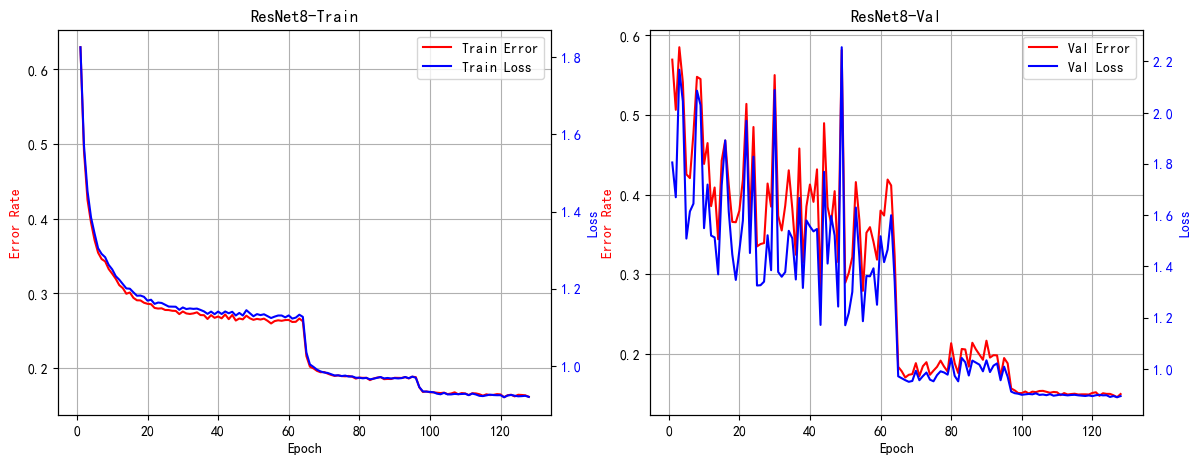

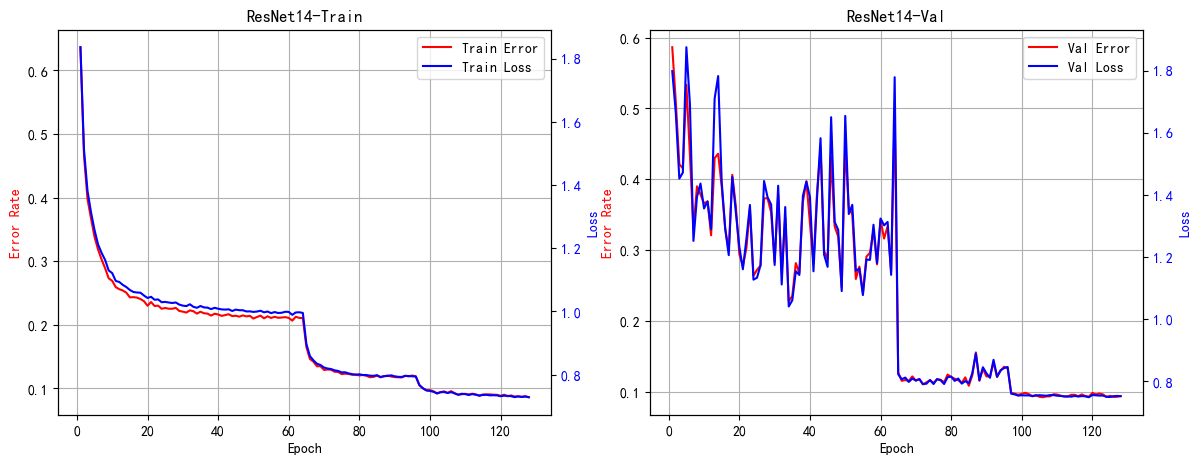

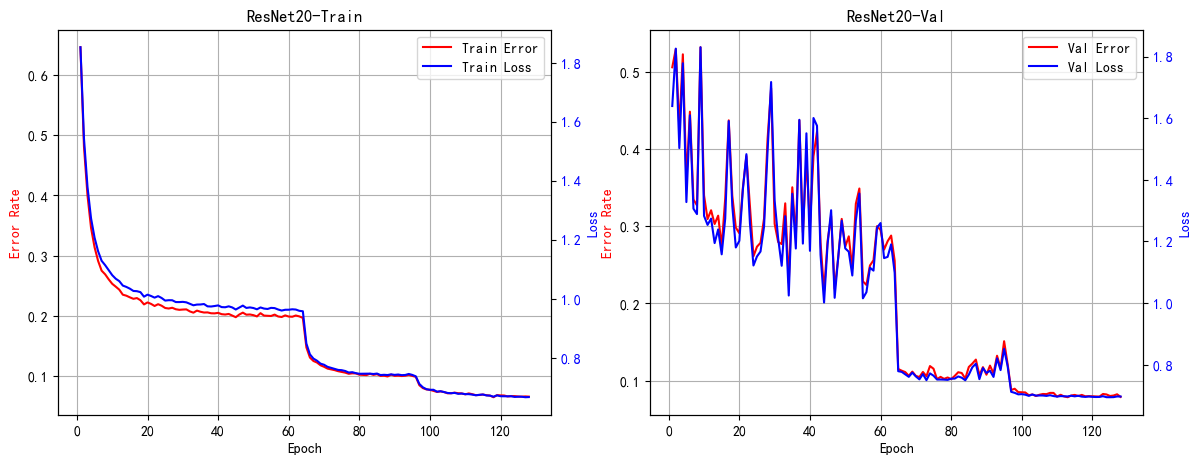

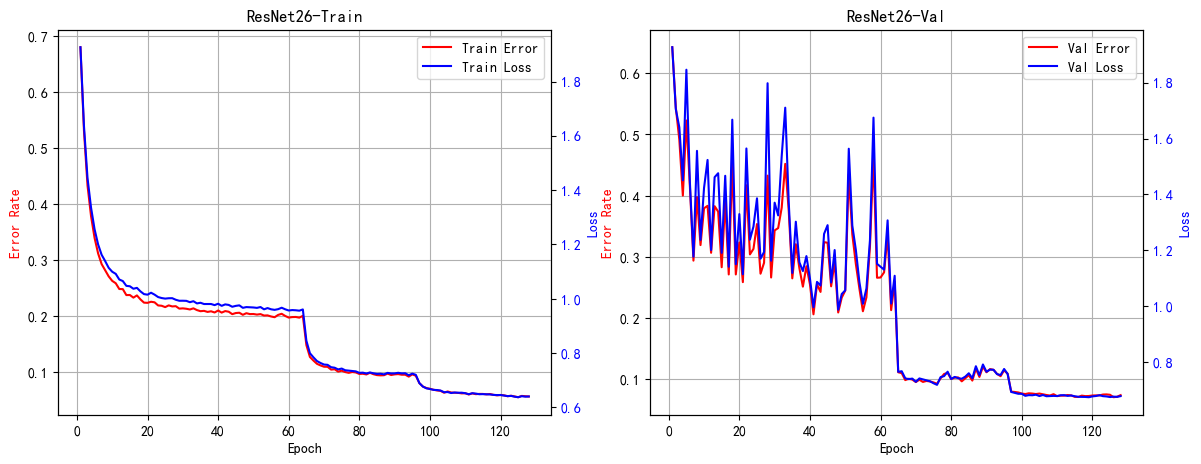

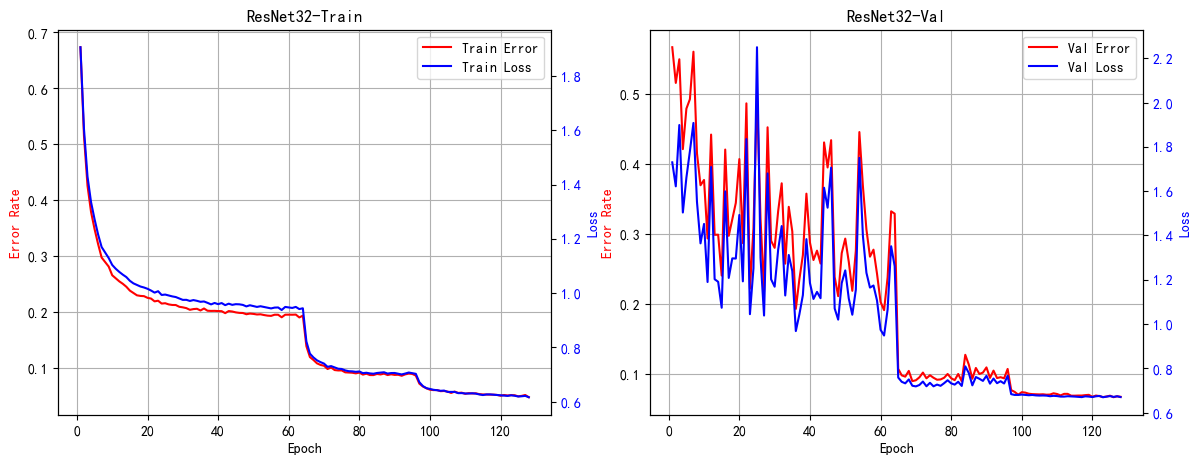

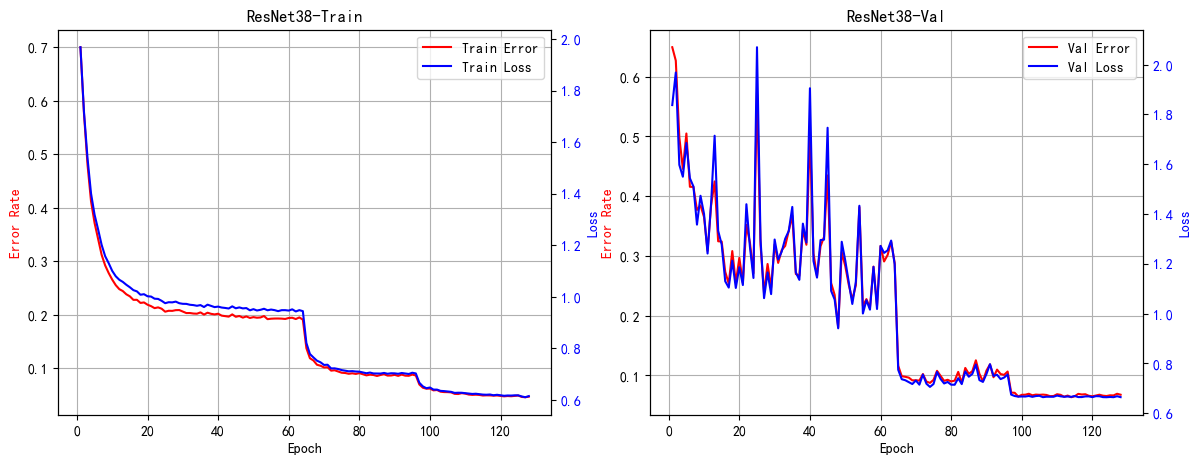

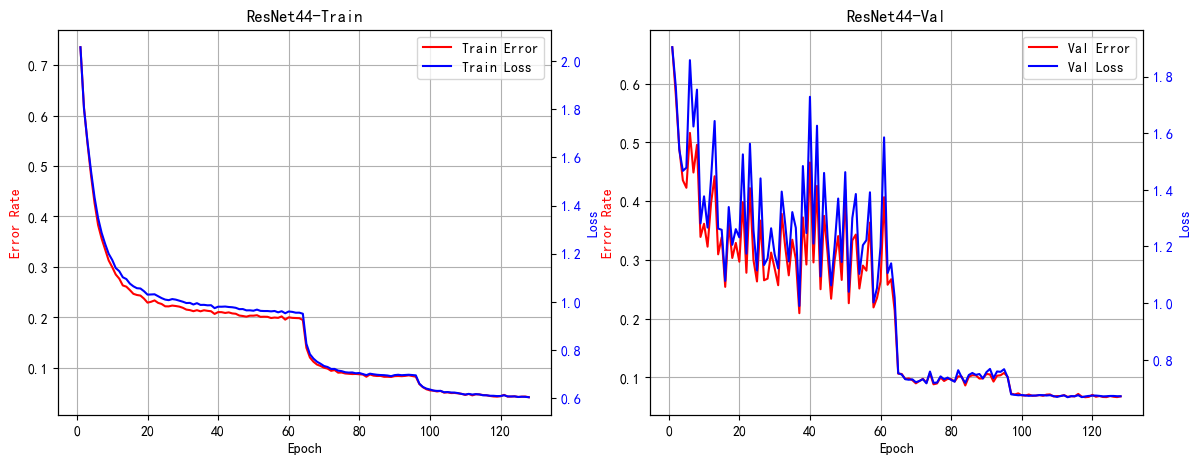

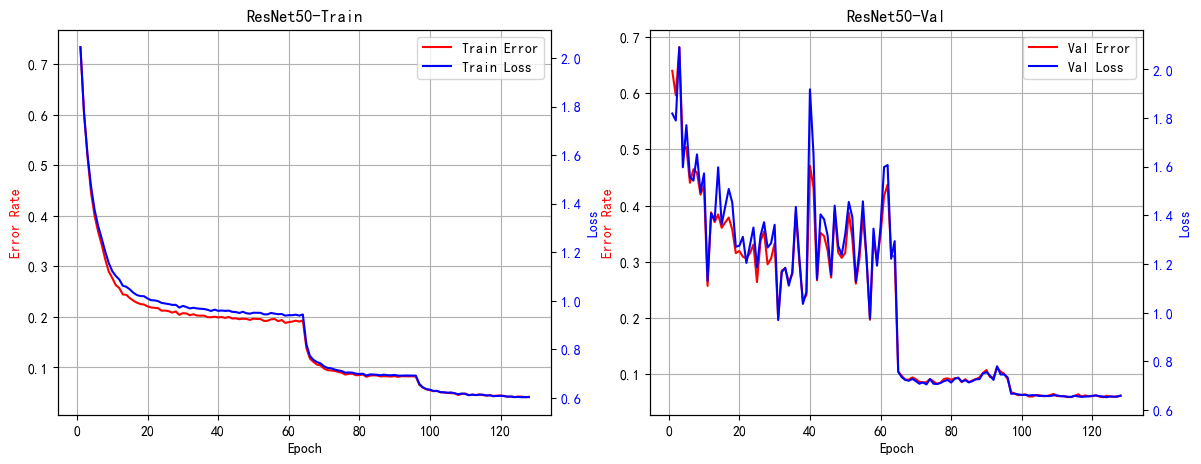

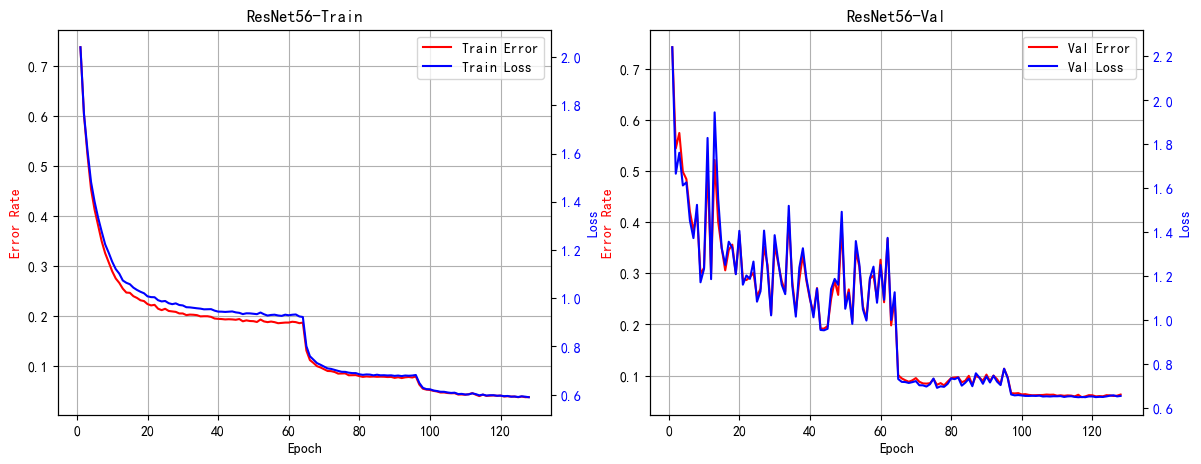

In [22]:
for n in range(9):
    History=history_list[n]
    X=range(1,129)
    VL=History['val_loss']
    VE=[1-acc for acc in History['val_acc']]
    TL=History['train_loss']
    TE=[1-acc for acc in History['train_acc']]

    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))

    ax1.plot(X,TE,'r',label='Train Error')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Error Rate',color='r')
    ax1.grid(True)
    ax1_twin=ax1.twinx()
    ax1_twin.plot(X,TL,'b',label='Train Loss')
    ax1_twin.set_ylabel('Loss',color='b')
    ax1_twin.tick_params(axis='y',labelcolor='b')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_twin.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,loc='best')
    ax1.set_title(f'ResNet{6*(n+1)+2}-Train')

    ax2.plot(X,VE,'r',label='Val Error')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Error Rate',color='r')
    ax2.grid(True)
    ax2_twin=ax2.twinx()
    ax2_twin.plot(X,VL,'b',label='Val Loss')
    ax2_twin.set_ylabel('Loss',color='b')
    ax2_twin.tick_params(axis='y',labelcolor='b')
    lines3, labels3 = ax2.get_legend_handles_labels()
    lines4, labels4 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines3 + lines4, labels3 + labels4,loc='best')
    ax2.set_title(f'ResNet{6*(n+1)+2}-Val')

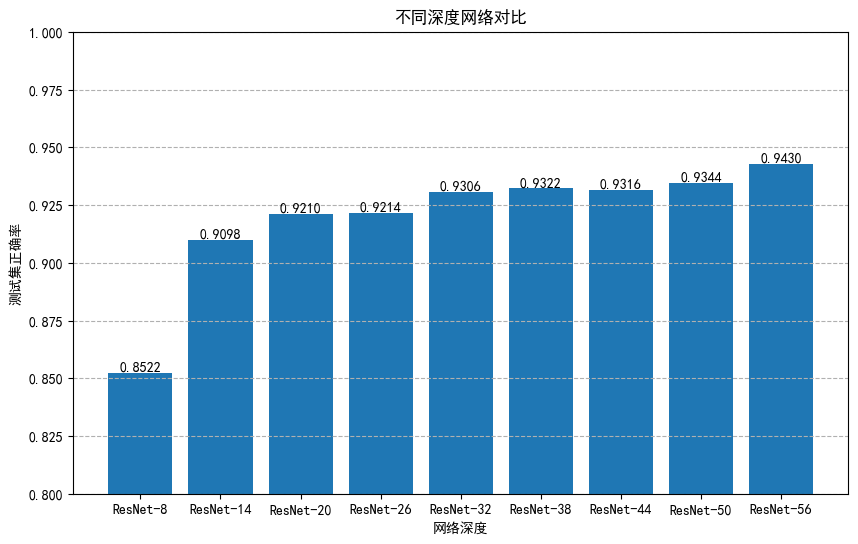

In [23]:
Name=[f'ResNet-{6*n+2}'for n in range(1,10)]
Y=acc_list

plt.figure(figsize=(10, 6))
bar=plt.bar(Name,Y)
plt.grid(axis='y',linestyle='--')
plt.bar_label(bar,fmt='%.4f')
plt.xlabel('网络深度')
plt.ylabel('测试集正确率')
plt.title('不同深度网络对比')
plt.ylim(0.8,1)
plt.show()